# 03 Dummy Baseline

This notebook trains the first supervised baseline: a majority-class `DummyClassifier`. Future image-derived models must beat this baseline, especially on balanced accuracy and macro F1.

## 1. Project setup

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

## 2. Imports

In [6]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mse446_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from src.train_dummy_baseline import (
    CLASS_LABELS,
    CONFUSION_MATRIX_FIGURE,
    METADATA_CSV,
    SCORES_CSV,
    evaluate_dummy_baseline,
    load_metadata,
    make_placeholder_features,
    save_confusion_matrix_figure,
    split_group_aware,
)

## 3. Paths and configuration

In [7]:
print(f"Metadata CSV: {METADATA_CSV}")
print(f"Scores CSV: {SCORES_CSV}")
print(f"Confusion matrix figure: {CONFUSION_MATRIX_FIGURE}")

Metadata CSV: /home/jp/MSE446_Nanoparticle_Ordering/data/dataset_metadata.csv
Scores CSV: /home/jp/MSE446_Nanoparticle_Ordering/results/model_scores_dummy.csv
Confusion matrix figure: /home/jp/MSE446_Nanoparticle_Ordering/results/figures/confusion_matrix_dummy.png


## 4. Load metadata

In [8]:
metadata = load_metadata(METADATA_CSV)
metadata.head()

,filename,path,kv,mm,label,sample,area,mag,image_id,original_filename,area_group,param_group
0,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,100,100-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
1,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,101,101-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
2,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,102,102-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
3,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,103,103-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
4,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,104,104-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k


## 5. Sanity checks

In [9]:
print(f"Rows: {len(metadata)}")
print("Label counts:")
print(metadata["label"].value_counts().sort_index())
print(f"Unique area groups: {metadata['area_group'].nunique()}")
assert metadata["label"].isin(CLASS_LABELS).all()

Rows: 1000
Label counts:
label
disordered    250
ordered       750
Name: count, dtype: int64
Unique area groups: 292


## 6. Main analysis

In [10]:
X = make_placeholder_features(len(metadata))
y = metadata["label"]
groups = metadata["area_group"]
train_idx, test_idx = split_group_aware(metadata)

train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])
assert train_groups.isdisjoint(test_groups)

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

model = DummyClassifier(strategy="most_frequent")
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

scores, report, matrix = evaluate_dummy_baseline(y_train, y_test, y_train_pred, y_test_pred)
scores

,model,strategy,train_accuracy,test_accuracy,test_balanced_accuracy,macro_precision,macro_recall,macro_f1,train_size,test_size
0,dummy_most_frequent,most_frequent,0.661716,0.885787,0.5,0.442893,0.5,0.469717,606,394


## 7. Results/figures

Raw accuracy is misleading because the dataset is imbalanced.
              precision    recall  f1-score   support

  disordered       0.00      0.00      0.00        45
     ordered       0.89      1.00      0.94       349

    accuracy                           0.89       394
   macro avg       0.44      0.50      0.47       394
weighted avg       0.78      0.89      0.83       394

Saved scores to /home/jp/MSE446_Nanoparticle_Ordering/results/model_scores_dummy.csv
Saved confusion matrix to /home/jp/MSE446_Nanoparticle_Ordering/results/figures/confusion_matrix_dummy.png


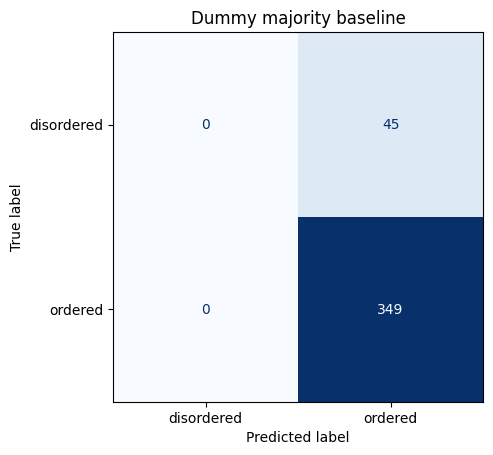

In [11]:
print("Raw accuracy is misleading because the dataset is imbalanced.")
print(report)

scores.to_csv(SCORES_CSV, index=False)
figure_path = save_confusion_matrix_figure(y_test, y_test_pred, CONFUSION_MATRIX_FIGURE)
print(f"Saved scores to {SCORES_CSV}")
print(f"Saved confusion matrix to {figure_path}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=CLASS_LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Dummy majority baseline")
plt.show()

## 8. Notes for report

- This baseline predicts the majority class from the training set for every test image.
- Balanced accuracy and macro F1 are more informative than raw accuracy for this imbalanced dataset.
- Later image-derived models should improve on this dummy baseline without using metadata as model inputs.